In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("cairo 2025-01-01 to 2025-12-31.csv")

In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"])
df.set_index("datetime", inplace=True)

In [ ]:
df.head(10)

In [ ]:
df.info()

In [ ]:
df.tail()

In [ ]:
df.isnull().sum()

In [ ]:
df.drop(columns=["severerisk"], inplace=True)
df.drop(columns=["preciptype"], inplace=True)

In [ ]:
# check sampling overview
print(pd.infer_freq(df.index))

In [ ]:
df[["temp", "precip"]].describe()

# The average temperature in Cairo during 2025 was about 23.4°C,
# with values ranging from 11.2°C to 34.7°C, showing normal seasonal changes.
#
# Rainfall was very low throughout the year. More than 75% of the days had
# no rainfall at all, and the highest recorded precipitation was only 1.1 mm.
# This matches Cairo's dry climate, where rain is rare.

In [ ]:
(df["precip"] > 0).sum()

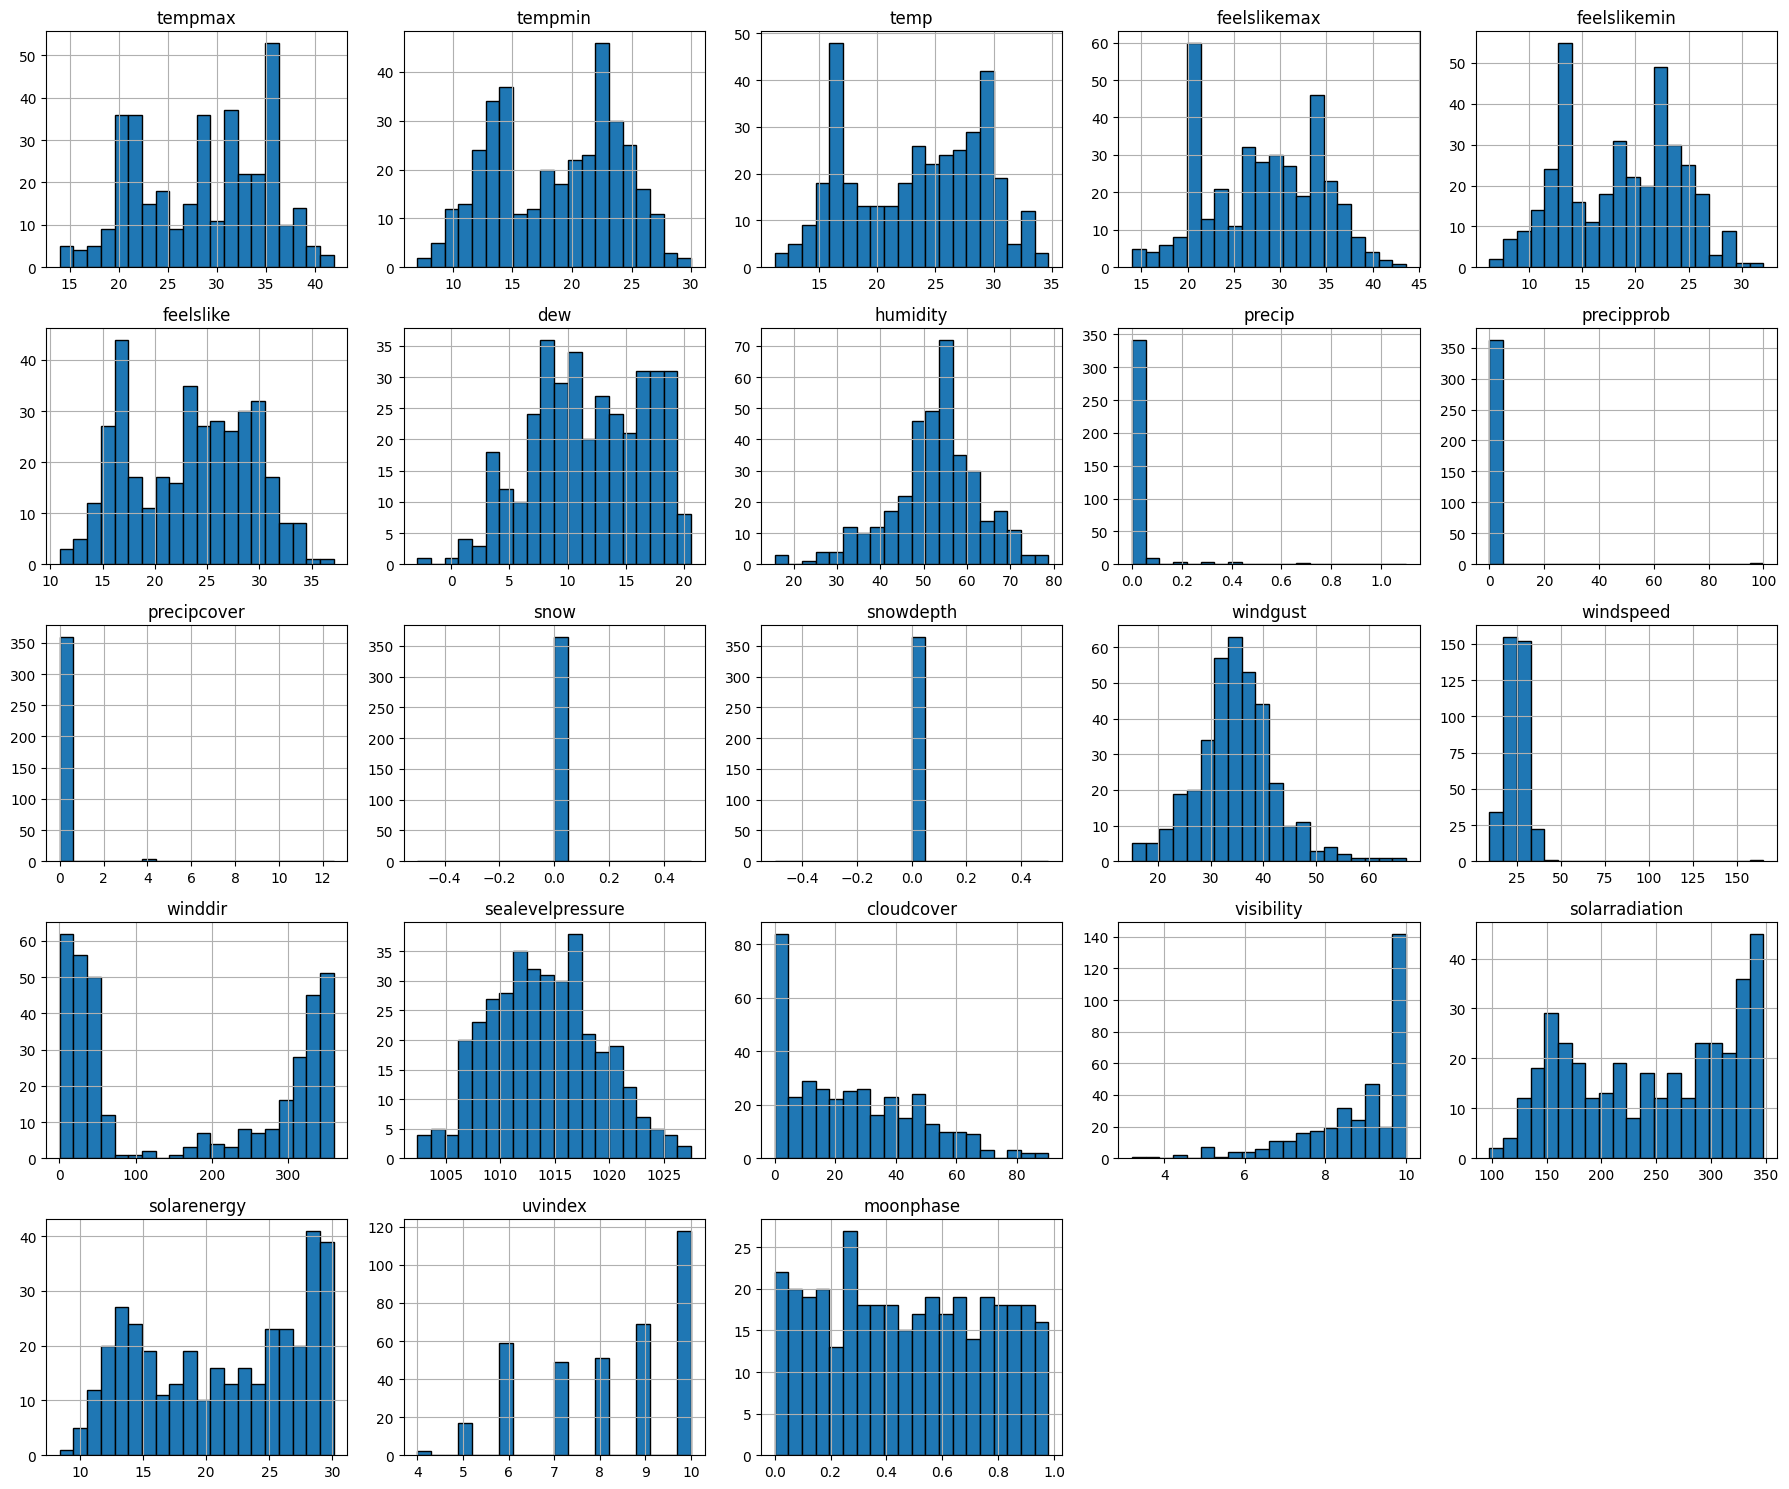

In [17]:


# Select all numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Plot histograms
numeric_df.hist(figsize=(18, 15), bins=20, edgecolor="black")

plt.tight_layout()
plt.show()

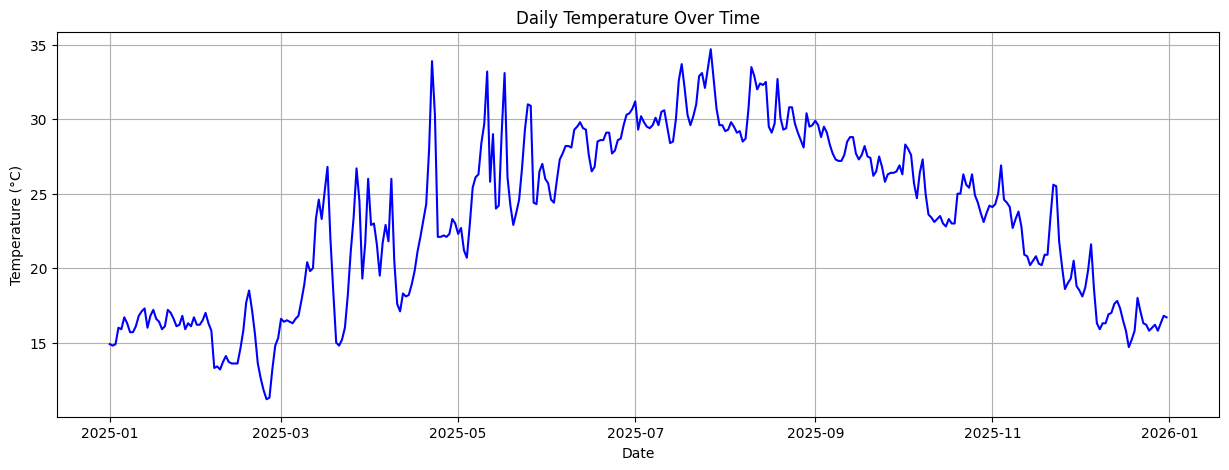

In [18]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["temp"], color="blue")

plt.title("Daily Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

# The temperature changes clearly throughout the year.
# It increases from winter to summer, reaches its highest values in July and August,
# then gradually decreases toward the end of the year.
# This indicates a clear seasonal pattern with normal daily fluctuations.

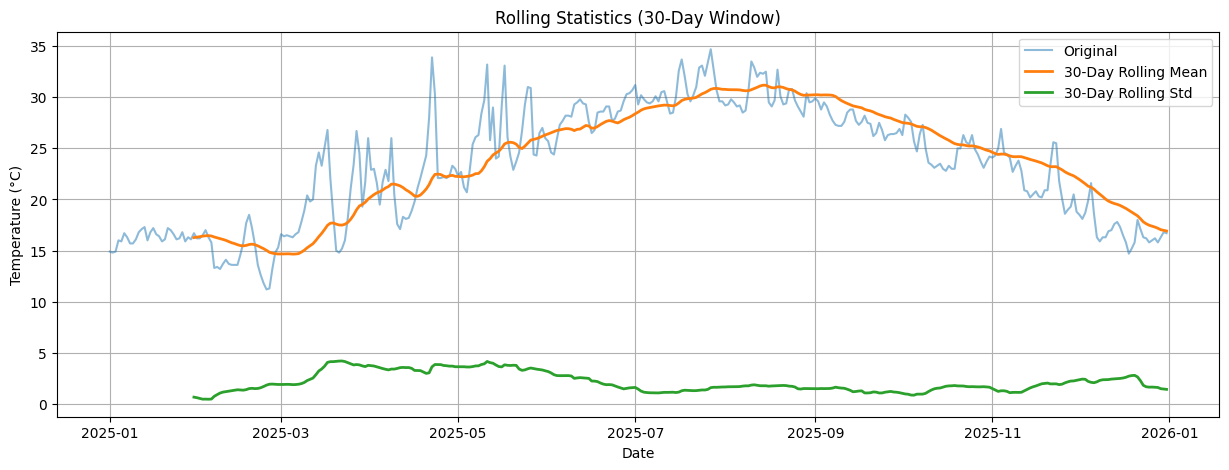

In [19]:
rolling_mean = df["temp"].rolling(window=30).mean()
rolling_std = df["temp"].rolling(window=30).std()

plt.figure(figsize=(15,5))

plt.plot(df.index, df["temp"], label="Original", alpha=0.5)
plt.plot(df.index, rolling_mean, label="30-Day Rolling Mean", linewidth=2)
plt.plot(df.index, rolling_std, label="30-Day Rolling Std", linewidth=2)

plt.title("Rolling Statistics (30-Day Window)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

# The rolling mean smooths the daily temperature values and makes the seasonal
# trend easier to observe. The rolling standard deviation measures the variation
# in temperature within each 30-day window. It shows that temperature variability
# changes over the year, with some periods being more stable than others.

<Figure size 1200x600 with 0 Axes>

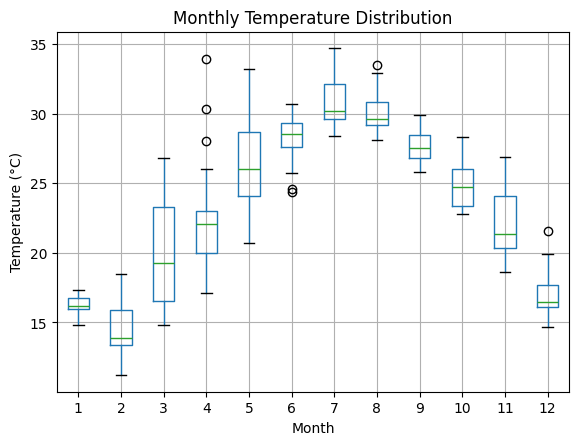

In [20]:
df["month"] = df.index.month
plt.figure(figsize=(12,6))

df.boxplot(column="temp", by="month")

plt.title("Monthly Temperature Distribution")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()

# The boxplot shows a clear seasonal pattern in Cairo's temperature.
# Winter months have the lowest temperatures, while summer months,
# especially July and August, have the highest temperatures.
# The spread of temperatures also varies across months,
# indicating different levels of temperature variability.

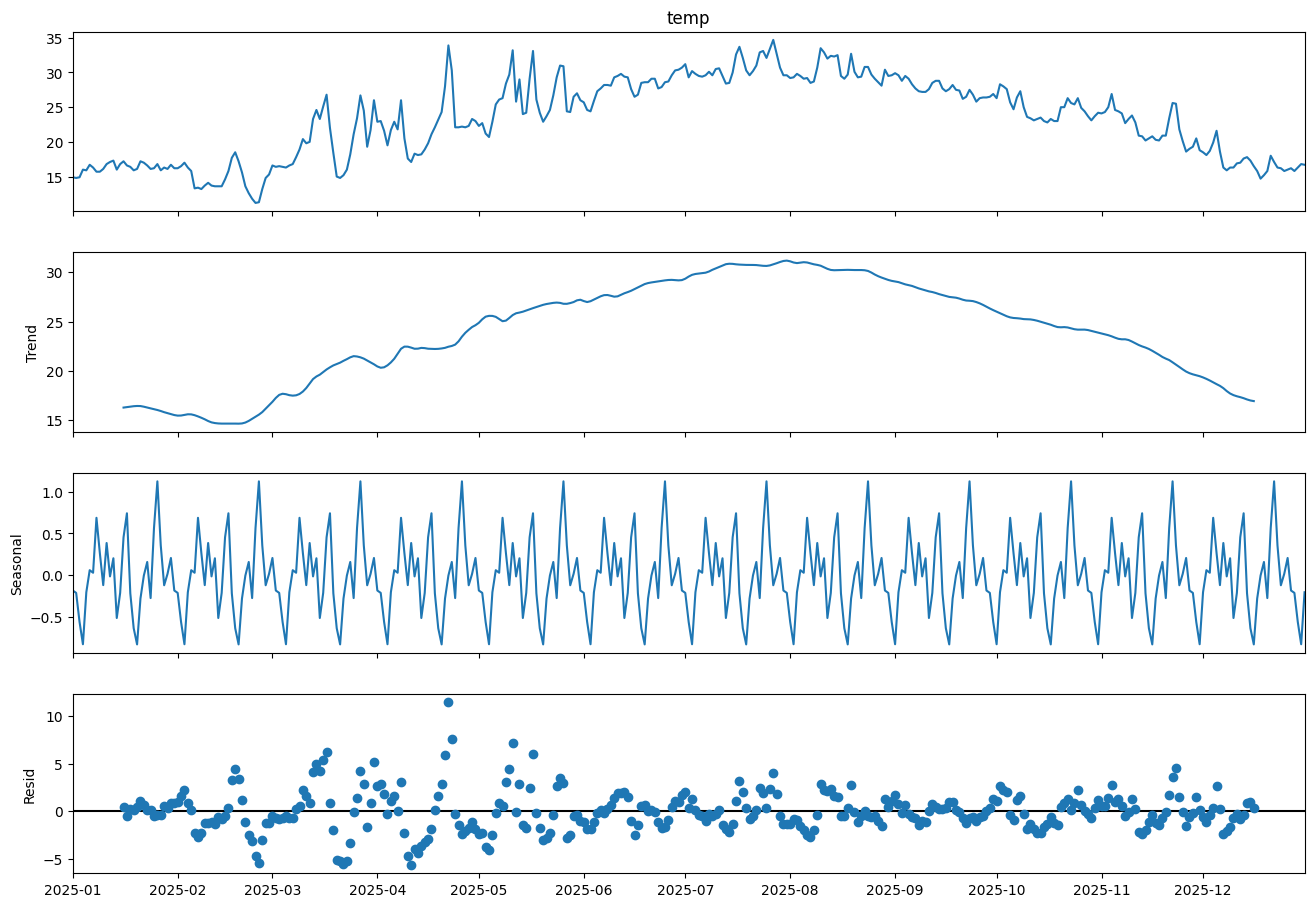

In [22]:
decomposition = seasonal_decompose(
    df["temp"],
    model="additive",
    period=30
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()

# The decomposition separates the temperature series into its main components.
# The trend shows that temperature increases from winter to summer and then
# decreases toward the end of the year. The seasonal component indicates a
# repeating pattern in the data, while the residual values are mostly centered
# around zero, suggesting that most of the variation is explained by the trend
# and seasonality.

In [24]:
result = adfuller(df["temp"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

    # The ADF test returned a p-value greater than 0.05,
# indicating that the temperature series is non-stationary.
# This is expected because the data shows both a clear trend
# and seasonal variation throughout the year.

ADF Statistic: -0.9971379909928646
p-value: 0.7543067213557972

Critical Values:
1%: -3.4490648539347544
5%: -2.8697861692116478
10%: -2.5711631253228306


<Figure size 1000x500 with 0 Axes>

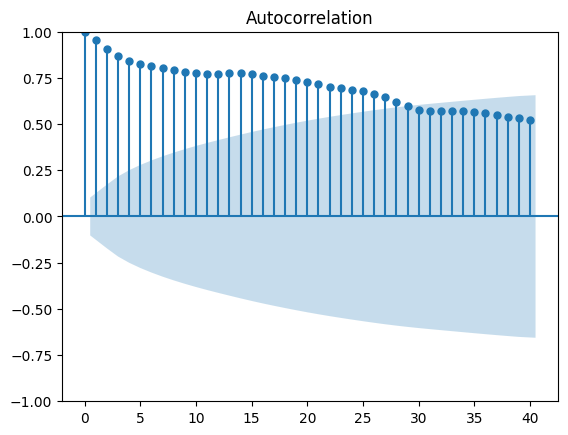

In [26]:
plt.figure(figsize=(10,5))

plot_acf(df["temp"], lags=40)

plt.show()

# The ACF plot shows a strong positive autocorrelation across many lags.
# The correlation decreases gradually rather than dropping quickly,
# indicating that temperature values are highly related to previous days.
# This behavior is consistent with a non-stationary time series.

<Figure size 1000x500 with 0 Axes>

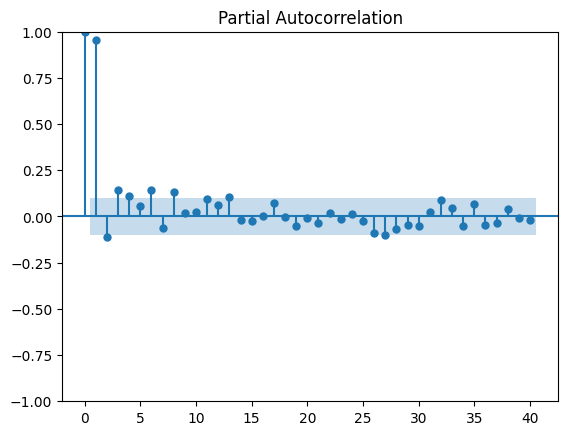

In [28]:
plt.figure(figsize=(10,5))

plot_pacf(df["temp"], lags=40)

plt.show()

# The PACF plot shows a strong direct correlation at lag 1,
# while the remaining lags have weak or insignificant direct correlations.
# This indicates that today's temperature is mainly influenced by the
# previous day's temperature, with little direct effect from earlier days.

In [29]:
corr = df[["temp", "precip", "humidity", "windspeed"]].corr()

corr

,temp,precip,humidity,windspeed
temp,1.000000,-0.188203,-0.450944,0.112437
precip,-0.188203,1.000000,0.153197,0.050051
humidity,-0.450944,0.153197,1.000000,-0.049068
windspeed,0.112437,0.050051,-0.049068,1.000000


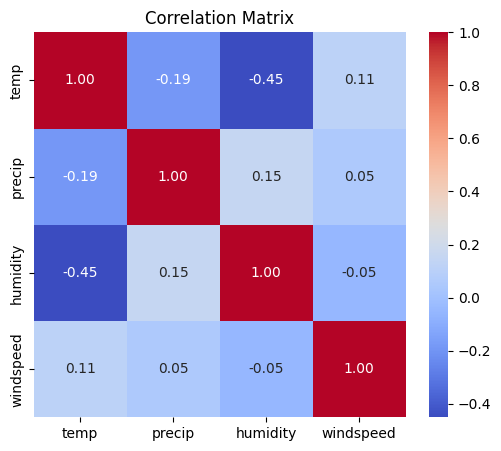

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

# Temperature has a moderate negative correlation with humidity (-0.45),
# indicating that higher humidity is generally associated with lower temperatures.
# It has a weak negative correlation with precipitation (-0.19) and a very weak
# positive correlation with wind speed (0.11), suggesting that these variables
# have only a small influence on temperature in this dataset.